# Final Assignment: Part 1 - Create Visualizations using Matplotlib, Seaborn & Folium

**IBM Data Visualization with Python – Automobile Sales Analysis**

This notebook contains the nine required visualizations for Part 1. The code is written to use the official IBM `historical_automobile_sales.csv` dataset directly, so no local CSV upload is required.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
df = pd.read_csv(URL)

print("Data downloaded and read into a dataframe!")
print("Shape:", df.shape)
df.head()

Data downloaded and read into a dataframe!
Shape: (528, 15)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


## 1.1 Average Annual Automobile Sales Fluctuation

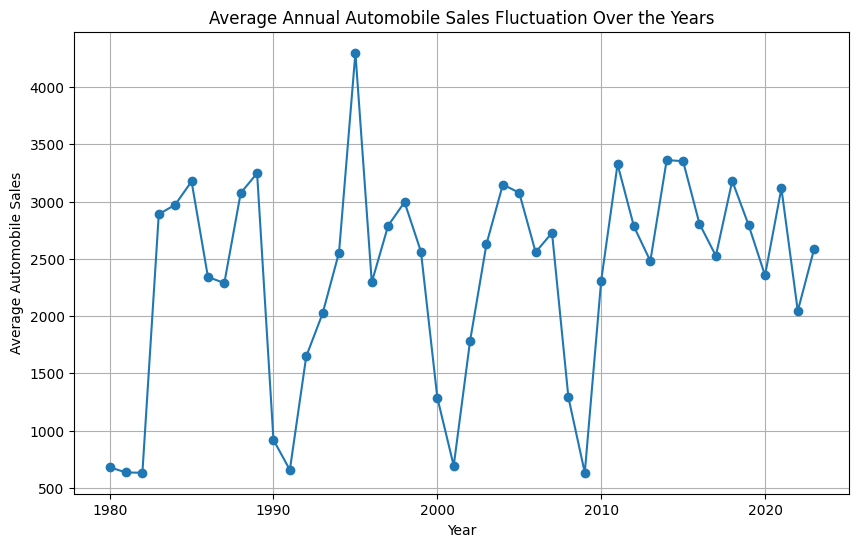

In [2]:
# Average Annual Automobile Sales
df_line = df.groupby('Year')['Automobile_Sales'].mean()

plt.figure(figsize=(10, 6))
df_line.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Average Annual Automobile Sales Fluctuation Over the Years')
plt.grid(True)
plt.show()

## 1.2 Advertising Expenditure and Automobile Sales During Non-Recession Periods

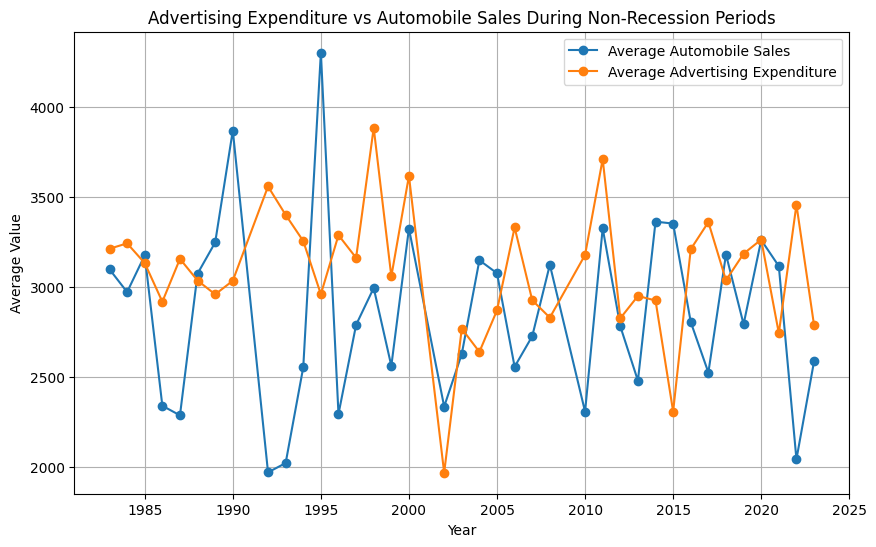

Correlation between advertising expenditure and automobile sales during non-recession periods: -0.035


In [3]:
# Non-recession data
non_rec_data = df[df['Recession'] == 0]

# Average annual sales and advertising expenditure
non_rec_yearly = non_rec_data.groupby('Year').agg({
    'Automobile_Sales': 'mean',
    'Advertising_Expenditure': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(non_rec_yearly['Year'], non_rec_yearly['Automobile_Sales'],
         marker='o', label='Average Automobile Sales')
plt.plot(non_rec_yearly['Year'], non_rec_yearly['Advertising_Expenditure'],
         marker='o', label='Average Advertising Expenditure')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Advertising Expenditure vs Automobile Sales During Non-Recession Periods')
plt.legend()
plt.grid(True)
plt.show()

# Correlation value
correlation = non_rec_data['Advertising_Expenditure'].corr(
    non_rec_data['Automobile_Sales']
)
print("Correlation between advertising expenditure and automobile sales during non-recession periods:",
      round(correlation, 3))

## 1.3 Vehicle-Wise Sales During Recession and Non-Recession Periods

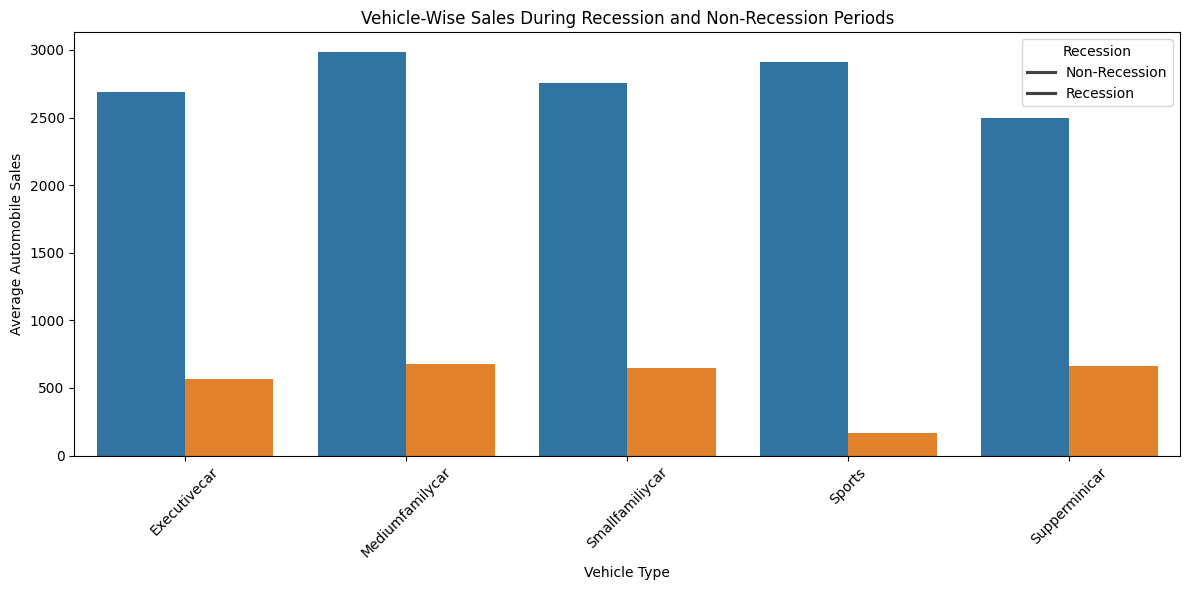

In [4]:
# Average vehicle-wise sales by recession status
vehicle_sales = df.groupby(
    ['Vehicle_Type', 'Recession']
)['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=vehicle_sales,
    x='Vehicle_Type',
    y='Automobile_Sales',
    hue='Recession'
)
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales During Recession and Non-Recession Periods')
plt.xticks(rotation=45)
plt.legend(title='Recession', labels=['Non-Recession', 'Recession'])
plt.tight_layout()
plt.show()

## 1.4 GDP Variations During Recession and Non-Recession Periods

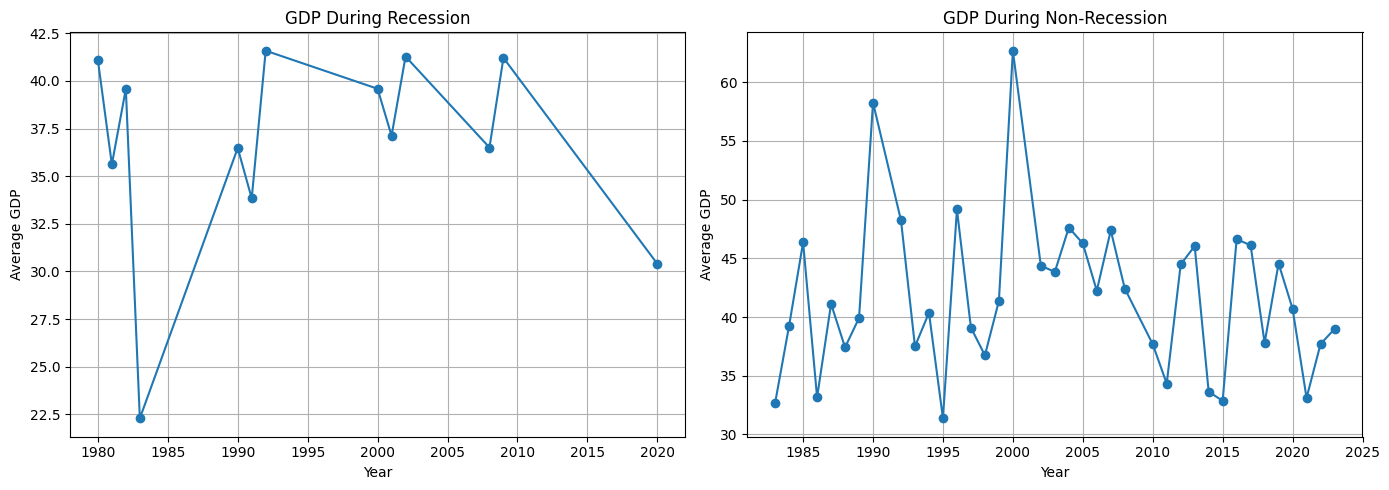

In [5]:
recession_data = df[df['Recession'] == 1]
non_recession_data = df[df['Recession'] == 0]

recession_gdp = recession_data.groupby('Year')['GDP'].mean()
non_recession_gdp = non_recession_data.groupby('Year')['GDP'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recession_gdp.index, recession_gdp.values, marker='o')
axes[0].set_title('GDP During Recession')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average GDP')
axes[0].grid(True)

axes[1].plot(non_recession_gdp.index, non_recession_gdp.values, marker='o')
axes[1].set_title('GDP During Non-Recession')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average GDP')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 1.5 Bubble Plot – Seasonality Impact on Automobile Sales

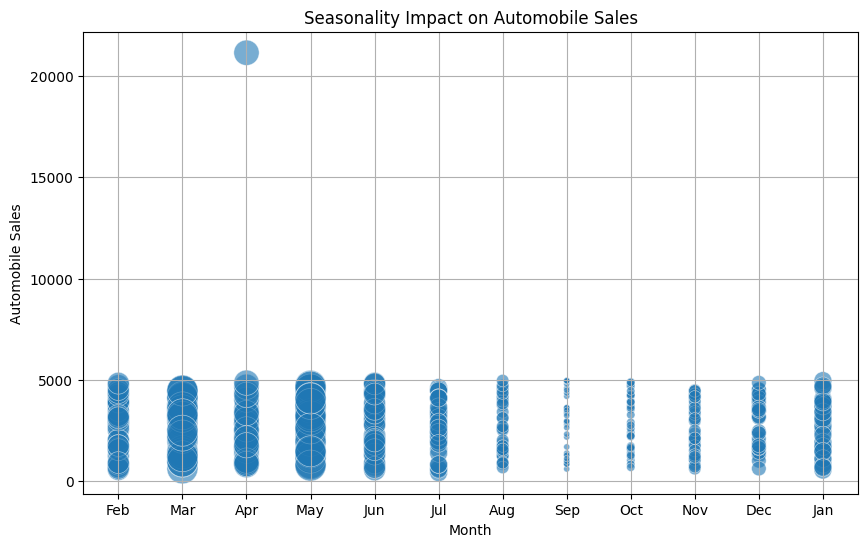

In [6]:
# Bubble plot using non-recession data to observe seasonality
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=non_rec_data,
    x='Month',
    y='Automobile_Sales',
    size='Seasonality_Weight',
    sizes=(20, 500),
    alpha=0.6,
    legend=False
)

plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality Impact on Automobile Sales')
plt.grid(True)
plt.show()

## 1.6 Price and Automobile Sales During Recession

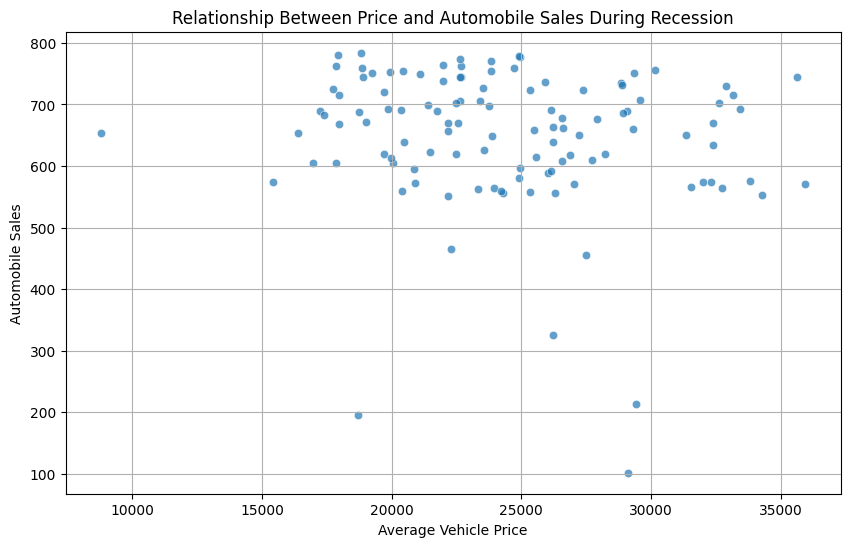

In [7]:
# Scatter plot for recession period
recession_data = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=recession_data,
    x='Price',
    y='Automobile_Sales',
    alpha=0.7
)
plt.xlabel('Average Vehicle Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship Between Price and Automobile Sales During Recession')
plt.grid(True)
plt.show()

## 1.7 Advertising Expenditure Distribution During Recession and Non-Recession

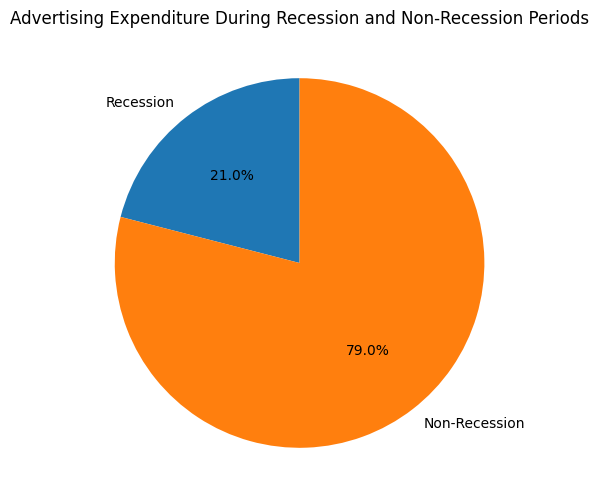

In [8]:
RAtotal = recession_data['Advertising_Expenditure'].sum()
NRAtotal = non_rec_data['Advertising_Expenditure'].sum()

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]

plt.figure(figsize=(8, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Advertising Expenditure During Recession and Non-Recession Periods')
plt.show()

## 1.8 Total Advertisement Expenditure by Vehicle Type During Recession

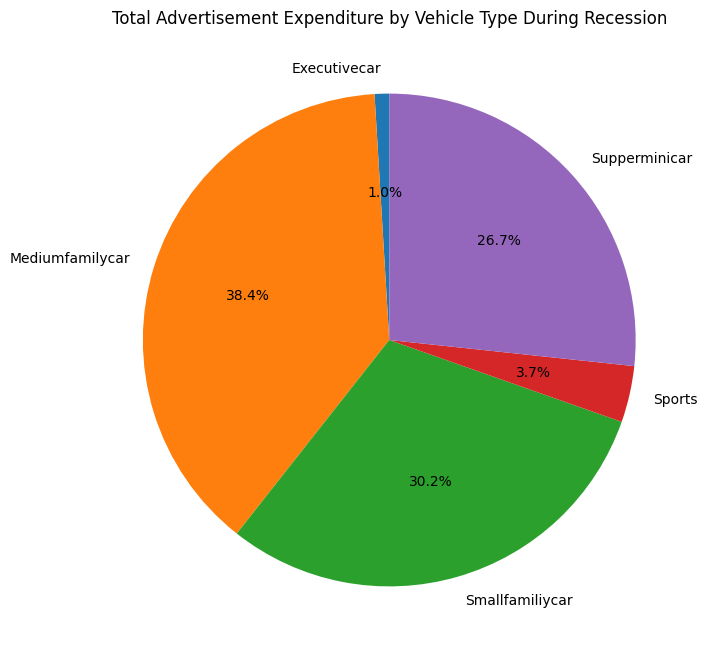

In [9]:
recession_ad = recession_data.groupby(
    'Vehicle_Type'
)['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    recession_ad.values,
    labels=recession_ad.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Total Advertisement Expenditure by Vehicle Type During Recession')
plt.show()

## 1.9 Effect of Unemployment Rate on Vehicle Type and Automobile Sales During Recession

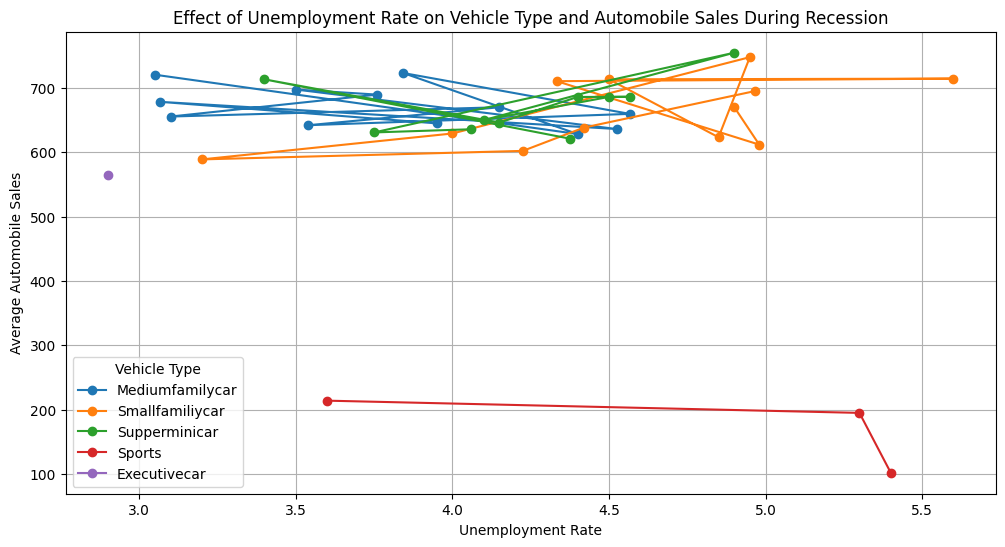

In [10]:
# Line plot showing unemployment rate and automobile sales
# for each vehicle type during recession
recession_vehicle = recession_data.groupby(
    ['Year', 'Vehicle_Type']
).agg({
    'unemployment_rate': 'mean',
    'Automobile_Sales': 'mean'
}).reset_index()

plt.figure(figsize=(12, 6))

for vehicle in recession_vehicle['Vehicle_Type'].unique():
    vehicle_data = recession_vehicle[
        recession_vehicle['Vehicle_Type'] == vehicle
    ]
    plt.plot(
        vehicle_data['unemployment_rate'],
        vehicle_data['Automobile_Sales'],
        marker='o',
        label=vehicle
    )

plt.xlabel('Unemployment Rate')
plt.ylabel('Average Automobile Sales')
plt.title('Effect of Unemployment Rate on Vehicle Type and Automobile Sales During Recession')
plt.legend(title='Vehicle Type')
plt.grid(True)
plt.show()

## Submission checklist

- [x] 1.1 Average Annual Automobile Sales line chart
- [x] 1.2 Advertising expenditure and automobile sales during non-recession
- [x] 1.3 Vehicle-wise sales bar chart for recession vs non-recession
- [x] 1.4 GDP comparison subplots
- [x] 1.5 Seasonality bubble plot
- [x] 1.6 Price vs automobile sales scatter plot during recession
- [x] 1.7 Advertising expenditure pie chart
- [x] 1.8 Advertisement expenditure by vehicle type pie chart
- [x] 1.9 Unemployment rate / vehicle type / automobile sales line plot

**Important:** Open this notebook in Google Colab and use **Runtime → Run all** before submitting so that every code cell has its executed output embedded in the `.ipynb` file.